# MODULE 3: SHAP tutorials
# IMAGE NEURONAL NETWORK



*   Task: image classification
*   Convolutional Neuronal Network: RESNET-50 model
*   Dataset: ImageNet competition



## CLASSIFICATION MODEL: RESNET-50

**ResNet** (Residual Network) is a deep learning architecture introduced by Microsoft Research in 2015

**ResNet-50** uses a 3-layer bottleneck (1x1, 3x3, 1x1 convolutions) to reduce computation while maintaining accuracy.



In [2]:
# LIBRARIES NEEDED

import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import shap
import os
import urllib.request



In [3]:
# CREATE THE MODEL: RESNET-50
model = ResNet50(weights='imagenet')


In [4]:
# CREATE THE  DATASET: IMAGENET

X, y = shap.datasets.imagenet50()

json_file_path = 'imagenet_class_index.json' # Verify if the JSON file is on disk
if os.path.exists(json_file_path):
  with open(json_file_path) as file:
    class_names = [v[1] for v in json.load(file).values()]
else:
  url = 'https://s3.amazonaws.com/deep-learning-models/' + 'image-models/imagenet_class_index.json'
  with urllib.request.urlopen(url) as response:
    json_data = response.read().decode()
  with open(json_file_path, 'w') as file:
    file.write(json_data)
  class_names = [v[1] for v in json.loads(json_data).values()]

In [5]:
# Wrapping the model
def predict(x):
  tmp = x.copy()
  preprocess_input(tmp)
  return model(tmp)
masker = shap.maskers.Image(
  'blur(128,128)', shape = X[0].shape
)
topk = 6 # original: 3
# which of the 50 images to display
index = [10, 28] # [21, 28]

### Creating SHAP explainer

In [ ]:
explainer = shap.Explainer(
    predict, masker, output_names=class_names
)

shap_values = explainer(
    X[index], max_evals=1000,
    batch_size=50,
    outputs=shap.Explanation.argsort.flip[:topk],
    silent=True
)

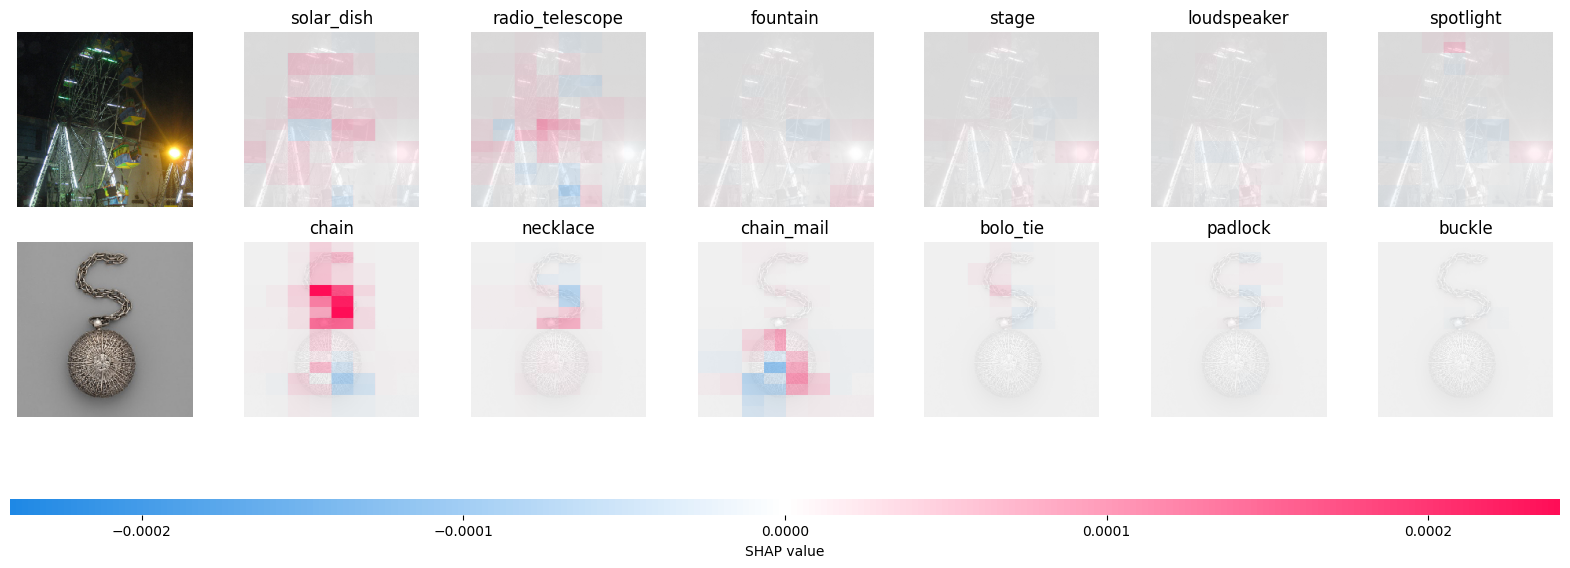

In [ ]:
shap.image_plot(shap_values, pixel_values=X[index]/255)